**Parameters to fit:** <br>
beta = 0.5<br>
deltaG1_0 = -10e3<br>
<br>
**Error parameters:** Standard deviations of each data point
<br> 
**Reference values:** E1_0 = E2_0 = 0 <br>
<br>
**BEP relation:** <br>
Gact2_0 = 100e3 + 0.5 * deltaG1_0<br>
Using Bayesian Optimization to calculate appropriate values for deltaG1_0 and beta. 

In [1]:
# Imports and constants

import numpy as np
import pymc as pm
import arviz as az
import xarray as xr
import matplotlib.pyplot as plt

R, T, F = 8.314, 298.15, 96485.3
kb, h = 1.3806e-23, 6.626e-34

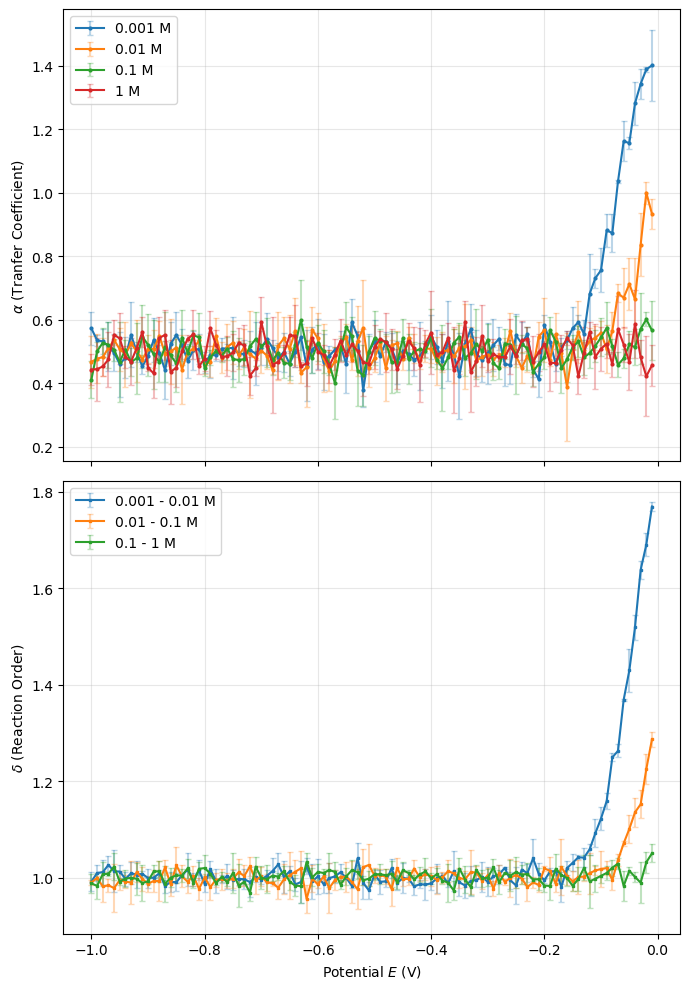

In [2]:
# Load data

files = ["fake_data1.npz", "fake_data2.npz", "fake_data3.npz"]
datasets = [np.load(f) for f in files]

def get_stats(key, data_list):
    stacked = np.stack([d[key] for d in data_list])    
    # Calculate mean and sample standard deviation (ddof=1) along the replicates (axis 0)
    return np.mean(stacked, axis=0), np.std(stacked, axis=0, ddof=1)

E_obs, _ = get_stats("E", datasets)
alpha_obs, alpha_std = get_stats("alpha", datasets)
delta_obs, delta_std = get_stats("delta", datasets)

dE = E_obs[1] - E_obs[0] # Voltage step size
concs = np.array([1e-3, 1e-2, 1e-1, 1e0]) # Proton concentrations
d_ln_c = np.diff(np.log(concs)) # Concentration step size


fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True, figsize=(7, 10))
for i, conc in enumerate(concs):
    eb = ax1.errorbar(E_obs, alpha_obs[:,i], yerr=alpha_std[:,i], 
                 fmt='-', marker='o', markersize=2, capsize=2, 
                 label=f'{conc:g} M')
    for artist in eb[1] + eb[2]: artist.set_alpha(0.3)
ax1.set_ylabel(r'$\alpha$ (Tranfer Coefficient)')
ax1.legend()
ax1.grid(True, alpha=0.3)
for i in range(len(concs) - 1):
    # Create a label indicating the range (e.g., "1e-3 -> 1e-2 M")
    label_text = f'{concs[i]:g} - {concs[i+1]:g} M'
    eb = ax2.errorbar(E_obs, delta_obs[:,i], yerr=delta_std[:,i], 
                 fmt='-', marker='s', markersize=2, capsize=2, 
                 label=label_text)
    for artist in eb[1] + eb[2]: artist.set_alpha(0.3)
ax2.set_ylabel(r'$\delta$ (Reaction Order)')
ax2.set_xlabel('Potential $E$ (V)')
ax2.legend()
ax2.grid(True, alpha=0.3)
plt.tight_layout()

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [beta, deltaG1_0]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 45 seconds.


Output()

               mean      sd    hdi_3%   hdi_97%  mcse_mean  mcse_sd  ess_bulk  \
beta          0.505   0.002     0.502     0.508      0.000    0.000    1505.0   
deltaG1_0 -9923.790  46.708 -9998.993 -9831.410      1.244    1.707    1864.0   

           ess_tail  r_hat  
beta         1628.0    1.0  
deltaG1_0    1120.0    1.0  


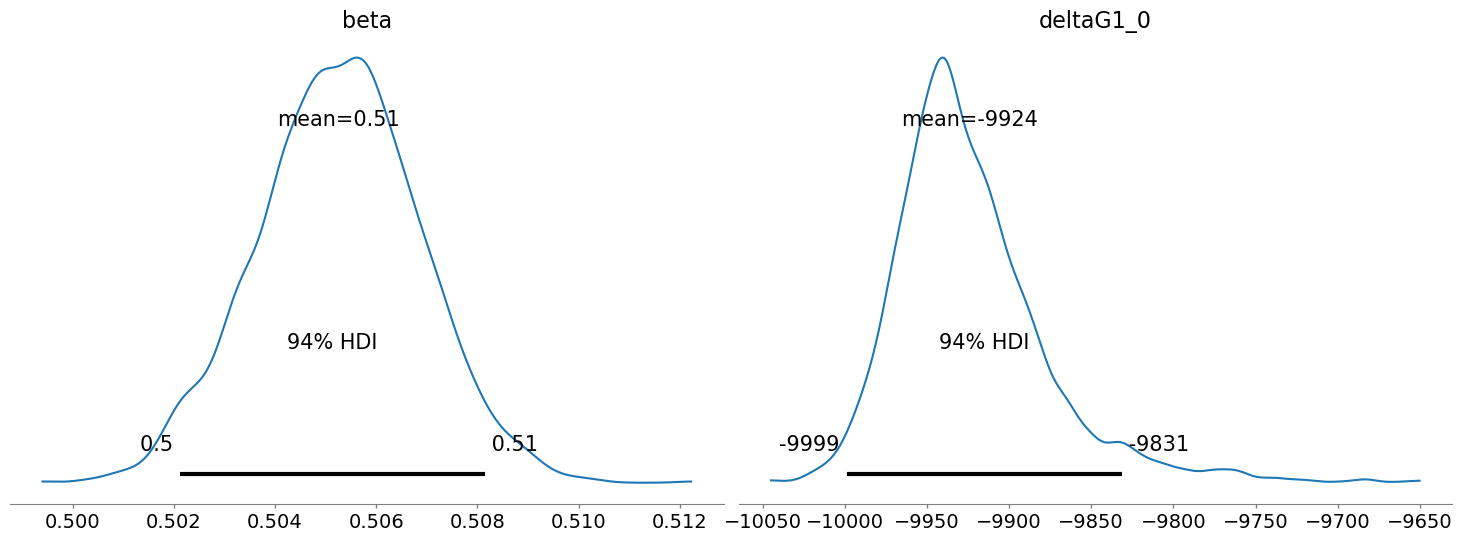

In [15]:
# Volmer-Heyrovsky model

with pm.Model() as VH:

    beta = pm.Uniform('beta', lower=0, upper=1)
    deltaG1_0 = pm.Normal('deltaG1_0', mu=-10e3, sigma=20e3)

    dG1 = deltaG1_0 + F*E_obs[:, None]
    K1 = pm.math.exp(-dG1/(R*T))
    Gact2 = (100e3 + 0.5*deltaG1_0) + beta*F*E_obs[:, None]
    k2 = (kb*T/h) * pm.math.exp(-Gact2/(R*T))

    theta = K1*concs[None, :]/(1+K1*concs[None, :])
    rate = k2*concs[None, :]*theta
    log_rate = pm.math.log(rate)

    mu_alpha = -(R*T/F) * (log_rate[1:, :]-log_rate[:-1, :]) / dE
    mu_delta = (log_rate[:, 1:] - log_rate[:, :-1]) / d_ln_c[None, :]
    alpha = pm.StudentT("alpha", nu=4, mu = mu_alpha, sigma = alpha_std[1:, :], observed = alpha_obs[1:, :])
    delta = pm.StudentT("delta", nu=4, mu = mu_delta, sigma = delta_std, observed = delta_obs)
    pm.Deterministic("total_log_lik", alpha.sum() + delta.sum())
    
with VH:
    idata_vh = pm.sample(target_accept=0.99)    
    pm.compute_log_likelihood(idata_vh)

print(az.summary(idata_vh, var_names=['beta', 'deltaG1_0']))
az.plot_posterior(idata_vh, var_names=['beta', 'deltaG1_0']); plt.tight_layout(); plt.show()

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [deltaG1_0]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 30 seconds.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


Output()

               mean        sd    hdi_3%   hdi_97%  mcse_mean  mcse_sd  \
deltaG1_0 -4477.914  1214.581 -5286.892 -2338.408    604.186  348.049   

           ess_bulk  ess_tail  r_hat  
deltaG1_0       7.0      37.0   1.53  


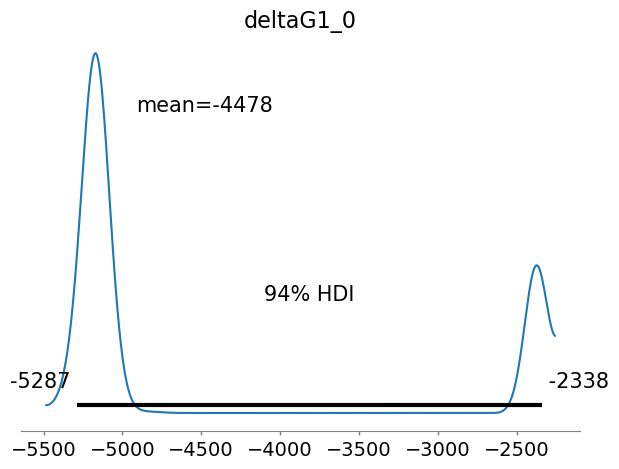

In [16]:
# Volmer-Tafel model

with pm.Model() as VT:

    deltaG1_0 = pm.Normal('deltaG1_0', mu=-10e3, sigma=20e3)

    dG1 = deltaG1_0 + F*E_obs[:, None]
    K1 = pm.math.exp(-dG1/(R*T))
    Gact2 = (100e3 + 0.5*deltaG1_0)
    k2 = (kb*T/h) * pm.math.exp(-Gact2/(R*T))

    theta = K1*concs[None, :]/(1+K1*concs[None, :])
    rate = k2*theta*theta
    log_rate = pm.math.log(rate)

    mu_alpha = -(R*T/F) * (log_rate[1:, :]-log_rate[:-1, :]) / dE
    mu_delta = (log_rate[:, 1:] - log_rate[:, :-1]) / d_ln_c[None, :]
    alpha = pm.StudentT("alpha", nu=4, mu = mu_alpha, sigma = alpha_std[1:, :], observed = alpha_obs[1:, :])
    delta = pm.StudentT("delta", nu=4, mu = mu_delta, sigma = delta_std, observed = delta_obs)
    pm.Deterministic("total_log_lik", alpha.sum() + delta.sum())
    
with VT:
    idata_vt = pm.sample(target_accept=0.99)
    pm.compute_log_likelihood(idata_vt)

print(az.summary(idata_vt, var_names=['deltaG1_0']))
az.plot_posterior(idata_vt, var_names=['deltaG1_0']); plt.tight_layout(); plt.show()

Drawing fit lines...


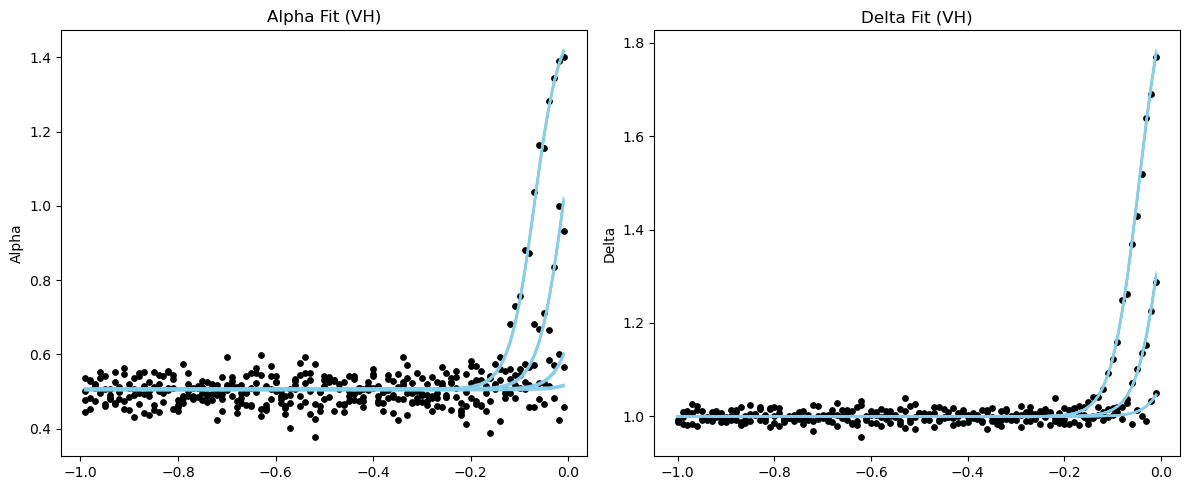

In [ ]:
betas = idata_vh.posterior["beta"].values.flatten()
dGs   = idata_vh.posterior["deltaG1_0"].values.flatten()
idxs  = np.random.randint(0, len(betas), 20) # Pick 20 random indices

fig, ax = plt.subplots(1, 2, figsize=(12, 5))

for i in idxs:
    # Get the "Knobs" for this specific guess
    b, dG = betas[i], dGs[i]
    
    dG1 = dG + F * E_obs[:, None]
    K1 = np.exp(-dG1 / (R * T))
    Gact2 = (100e3 + 0.5*dG) + b * F * E_obs[:, None]
    theta = (K1 * concs[None, :]) / (1 + K1 * concs[None, :])
    rate = (kb * T / h) * np.exp(-Gact2 / (R * T)) * concs[None, :] * theta
    
    log_rate = np.log(rate)
    mu_alpha = -(R*T/F) * (log_rate[1:] - log_rate[:-1]) / dE
    mu_delta = (log_rate[:, 1:] - log_rate[:, :-1]) / d_ln_c[None, :]
    
    ax[0].plot(E_obs[1:], mu_alpha, color="skyblue", alpha=0.3)
    ax[1].plot(E_obs, mu_delta, color="skyblue", alpha=0.3)

for j in range(len(concs)):
    ax[0].scatter(E_obs[1:], alpha_obs[1:, j], color="k", s=15, label=f"C={concs[j]}")

for j in range(delta_obs.shape[1]):
    ax[1].scatter(E_obs, delta_obs[:, j], color="k", s=15)

ax[0].set_title("Alpha Fit (VH)"); ax[0].set_ylabel("Alpha")
ax[1].set_title("Delta Fit (VH)"); ax[1].set_ylabel("Delta")
plt.tight_layout(); plt.show()

Drawing curves...


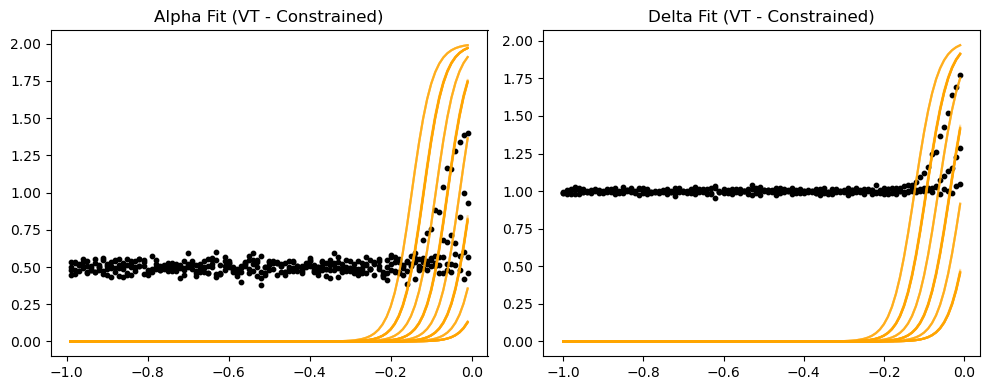

In [ ]:
post = idata_vt.posterior
dGs = post["deltaG1_0"].values.flatten()
idxs = np.random.choice(len(dGs), 20)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
ax1.set_title("Alpha Fit (VT)"); ax2.set_title("Delta Fit (VT)")

for i, c in enumerate(concs): ax1.scatter(E_obs[1:], alpha_obs[1:, i], c='k', s=10)
for i in range(delta_obs.shape[1]): ax2.scatter(E_obs, delta_obs[:, i], c='k', s=10)

for i in idxs:
    dG = dGs[i]
    
    dG1 = dG + F * E_obs[:, None]
    K1 = np.exp(-dG1 / (R * T))
    Gact2 = (100e3 + 0.5 * dG)
    k2 = (kb * T / h) * np.exp(-Gact2 / (R * T))
    theta = (K1 * concs) / (1 + K1 * concs)
    rate = k2 * (theta ** 2)
    
    log_rate = np.log(rate)
    mu_alpha = -(R*T/F) * (log_rate[1:] - log_rate[:-1]) / dE
    mu_delta = (log_rate[:, 1:] - log_rate[:, :-1]) / d_ln_c[None, :]
    
    ax1.plot(E_obs[1:], mu_alpha, c='orange', alpha=0.3)
    ax2.plot(E_obs, mu_delta, c='orange', alpha=0.3)

plt.tight_layout(); plt.show()

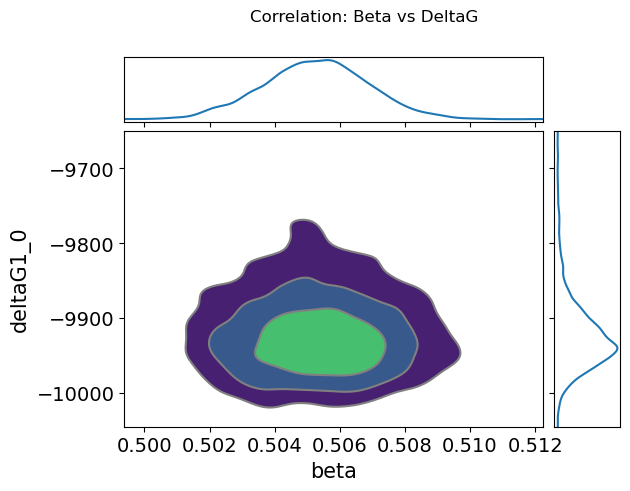

In [25]:
az.plot_pair(
    idata_vh, 
    var_names=["beta", "deltaG1_0"], 
    kind="kde", 
    marginals=True
)
plt.suptitle("Correlation: Beta vs DeltaG")
plt.show()

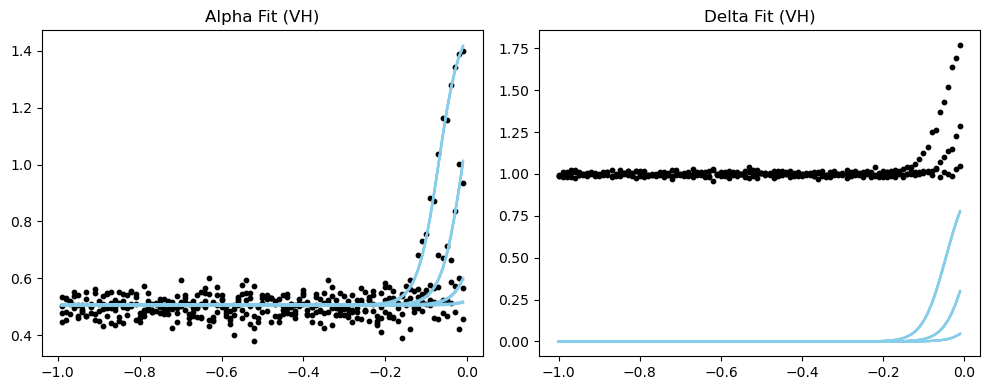

In [27]:
# --- COMPACT VISUALIZATION (VH) ---
# 1. Grab 20 random samples
post = idata_vh.posterior
betas = post["beta"].values.flatten()
dGs = post["deltaG1_0"].values.flatten()
idxs = np.random.choice(len(betas), 20)

# 2. Setup Plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
ax1.set_title("Alpha Fit (VH)"); ax2.set_title("Delta Fit (VH)")

# 3. Plot Data (Black Dots)
for i, c in enumerate(concs): ax1.scatter(E_obs[1:], alpha_obs[1:, i], c='k', s=10)
for i in range(delta_obs.shape[1]): ax2.scatter(E_obs, delta_obs[:, i], c='k', s=10)

# 4. Plot Model (Blue Lines)
for i in idxs:
    # Physics Recalculation
    dG1 = dGs[i] + F * E_obs[:, None]
    K1 = np.exp(-dG1 / (R * T))
    rate = (kb*T/h) * np.exp(-((100e3 + 0.5*dGs[i]) + betas[i]*F*E_obs[:, None])/(R*T)) * (K1*concs)/(1+K1*concs)
    
    # Slopes
    lr = np.log(rate)
    mu_alpha = -(R*T/F) * (lr[1:] - lr[:-1]) / (E_obs[1]-E_obs[0])
    mu_delta = (lr[:, 1:] - lr[:, :-1]) / np.diff(np.log(concs))
    
    ax1.plot(E_obs[1:], mu_alpha, c='skyblue', alpha=0.3)
    ax2.plot(E_obs, mu_delta, c='skyblue', alpha=0.3)

plt.tight_layout(); plt.show()